# K Means Clustering and Comparison with Custom Regex Rules
**This notebook is to find the optimal K value for K Means Clustering and comparing the results with manual segmentation rules to determine which one is better.**

### Importing packages and config file to read the dataset.

In [302]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sys.path.append(os.path.abspath(".."))

from config import RFM_DATA_PATH,DATA_DIR

In [303]:
df=pd.read_csv(RFM_DATA_PATH)
df.head(
)

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score,customer_segmentation
0,12346,326,1,77183.60,1,1,5,115,Standard Customer
1,12347,2,7,4310.00,5,5,5,555,VIP
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,Standard Customer
4,12350,310,1,334.40,1,1,2,112,Hibernating


### Log Transformed to reduce skewness.

In [304]:
df_new = np.log1p(df[["Recency","Frequency","Monetary"]])
df_new.rename(columns={"Recency":"log_recency","Frequency":"log_frequency","Monetary":"log_monetary"},inplace=True)
df_new.head()

,log_recency,log_frequency,log_monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


### Standardized the data into the same scale for K Means training.

In [305]:
ss=StandardScaler()
scaled_data = ss.fit_transform(df_new)

In [306]:
inertia=[]
for cnt in range(1,11):
    kmeans = KMeans(n_clusters=cnt,random_state=42).fit(scaled_data)
    inertia.append(kmeans.inertia_)

### Plot the inertia (how tightly grouped) for different values of K to find the optimal one.

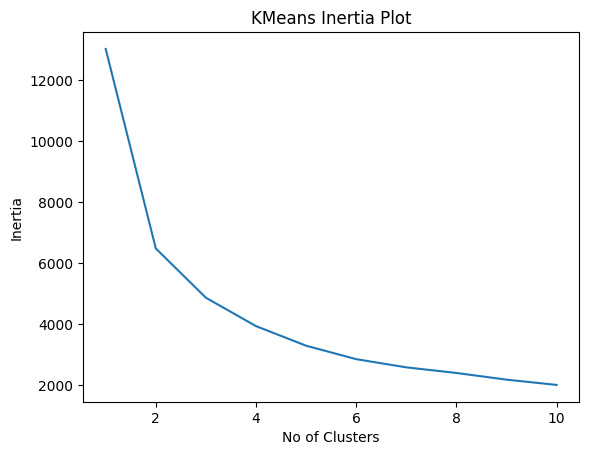

In [307]:
sns.lineplot(y=inertia,x=range(1,11)).set_title("KMeans Inertia Plot")
plt.xlabel("No of Clusters")
plt.ylabel("Inertia")
plt.show()

**The value K=4 was chosen as the rate of decrease drops significantly from that point onwards.**

In [308]:
kmeans_model = KMeans(n_clusters=4,random_state=42).fit(scaled_data)
df["ml_cluster"] = kmeans_model.labels_

In [309]:
df["ml_cluster"].value_counts()

ml_cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64

### Different visualizations of the ML clusters using K=4.

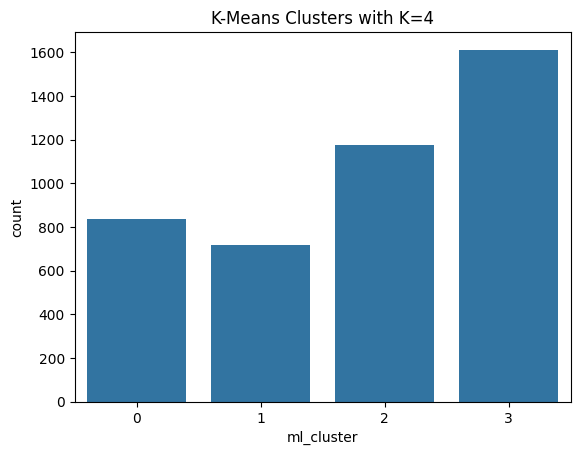

In [310]:
sns.countplot(data=df,x="ml_cluster").set_title("K-Means Clusters with K=4")
plt.show()

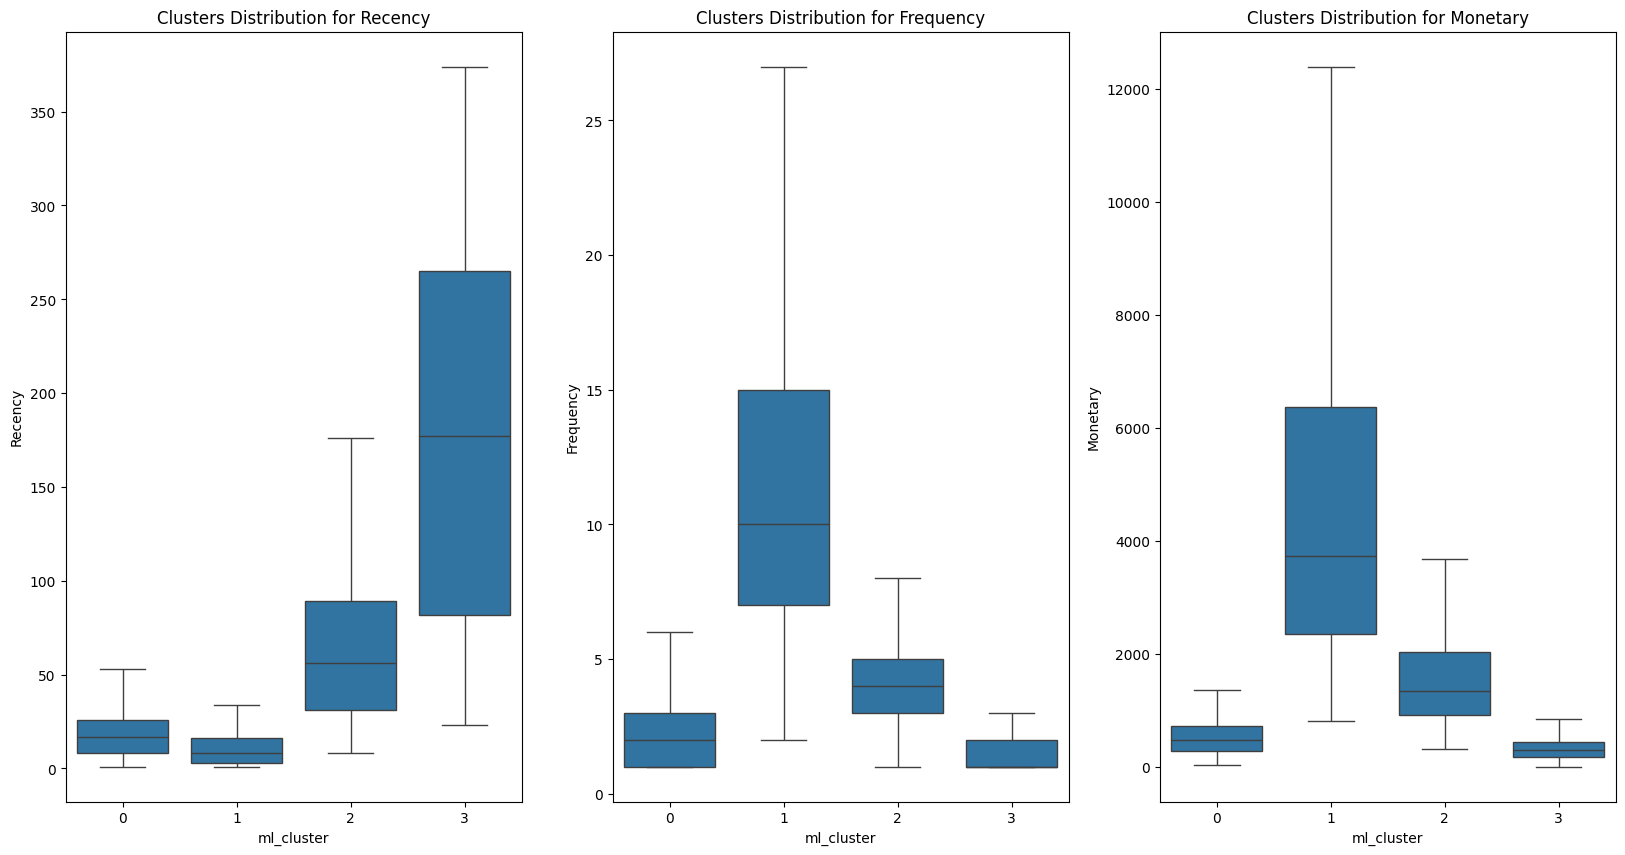

In [311]:
fig,axes = plt.subplots(1,3,figsize=(20,10))

sns.boxplot(data=df,y="Recency",x="ml_cluster",ax=axes[0],showfliers=False).set_title("Clusters Distribution for Recency")
sns.boxplot(data=df,y="Frequency",x="ml_cluster",ax=axes[1],showfliers=False).set_title("Clusters Distribution for Frequency")
sns.boxplot(data=df,y="Monetary",x="ml_cluster",ax=axes[2],showfliers=False).set_title("Clusters Distribution for Monetary")

plt.show()

In [312]:
pd.pivot_table(df,values=["Recency","Frequency","Monetary"],index="ml_cluster",aggfunc="mean").round(2)

,Frequency,Monetary,Recency
ml_cluster,,,
0,2.15,551.82,18.12
1,13.71,8074.27,12.13
2,4.08,1802.83,71.08
3,1.32,343.45,182.50


The box and whiskers plot and the pivot table suggests that K Means captured our four major custom segmentations where cluster 0 represents "New Customers", cluster 1 represents "VIP", cluster 2 represents "At Risk" and finally cluster 3 represents "Hibernating". So we rename the clsuters into meaningful terms.

In [313]:
df["ml_cluster"] = df["ml_cluster"].replace({0:"New Buyers",1:"Elite Buyers",2:"At Risk Buyers",3:"Hibernating Buyers"})
df.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score,customer_segmentation,ml_cluster
0,12346,326,1,77183.60,1,1,5,115,Standard Customer,At Risk Buyers
1,12347,2,7,4310.00,5,5,5,555,VIP,Elite Buyers
2,12348,75,4,1797.24,2,4,4,244,At Risk,At Risk Buyers
3,12349,19,1,1757.55,4,1,4,414,Standard Customer,New Buyers
4,12350,310,1,334.40,1,1,2,112,Hibernating,Hibernating Buyers


### Fix the structure of the data to do a snake plot.

In [314]:
group_df = df.groupby("ml_cluster")[["Recency","Frequency","Monetary"]].mean()
group_df = np.log1p(group_df).reset_index()
melt_df = pd.melt(group_df,id_vars=["ml_cluster"],value_vars=["Recency","Frequency","Monetary"])
melt_df = melt_df.rename(columns={"variable":"metric"})
melt_df

,ml_cluster,metric,value
0,At Risk Buyers,Recency,4.277838
1,Elite Buyers,Recency,2.574998
2,Hibernating Buyers,Recency,5.212198
3,New Buyers,Recency,2.950957
4,At Risk Buyers,Frequency,1.626009
5,Elite Buyers,Frequency,2.688778
6,Hibernating Buyers,Frequency,0.840808
7,New Buyers,Frequency,1.146814
8,At Risk Buyers,Monetary,7.497667
9,Elite Buyers,Monetary,8.996561


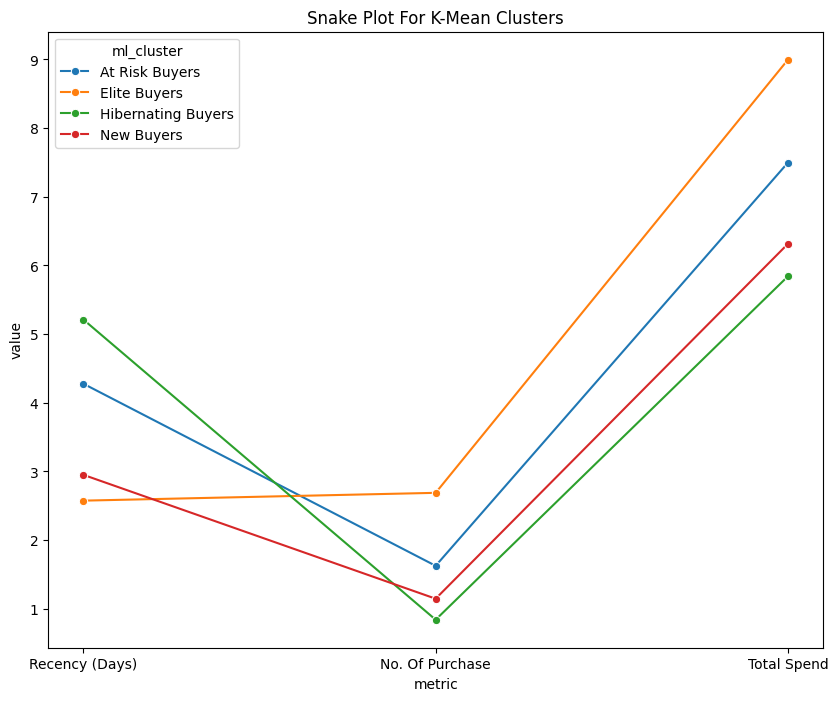

In [318]:
plt.figure(figsize=(10,8))
sns.lineplot(melt_df,x="metric",y="value",hue="ml_cluster",marker="o").set_title("Snake Plot For K-Mean Clusters")
plt.xticks(ticks=[0,1,2],labels=["Recency (Days)","No. Of Purchase","Total Spend"])
plt.show()

**Key Obserbations from the snake plot**
- **At Risk Buyers-** Their recency is high indicating last purchase was not recently along with high frequency and money spent indicating they once were the "Elit Buyers" who are considering shifting.
- **Elite Buyers-** The group with the highest money spent and most frequent shopping with a dip for recency showing these are customers with high and frequent engagement.
- **Hibernating Buyers-** Their last purchase records are the oldest with the up-to-date total number of purchase and total money spent are lowest.
- **New Buyers-** As the name suggests, they are new customers who recently started buying and as expected have a low number of purchase and money spent.

### Transition Matrix to compare how related are the manual segmentation and the ML clustering

In [316]:
pd.crosstab(df["customer_segmentation"],df["ml_cluster"])

ml_cluster,At Risk Buyers,Elite Buyers,Hibernating Buyers,New Buyers
customer_segmentation,,,,
At Risk,233,5,37,0
Hibernating,0,0,464,0
Loyal Customers,282,216,0,172
New Customers,0,0,0,42
Potential Customers,54,2,4,432
Standard Customer,598,31,1107,190
VIP,6,462,0,1


The transition matrix helped us understand how important it is to apply machine learning for CRM rather than blindly relying on manual hard coded rules.

**Key Obsertations**
- The manual segmentation allocated 31 VIP customers as standard customers which could in future push them towards hibernating. This might be due to the customers barely missing the threshold set through hard-coded rules.

- 282 of the "Loyal Customers" and 598 of the "Standard Customers" from manual rules were detected as "At Risk Buyers" which means the marketing team is not taking any specific step to ensure these "At Risk" customers retain their interest in this business and thus pushing them towards hibernating. Hard coded rules might have taken their lifetime purchases and labeling them wrongly.

- Standard customers were supposed to be regular buyers but 1107 of them were already hibernating which means they are gone but the marketing team is still allocating the email budget for these customers and sending them weekly promotional emails.

In [317]:
df[["CustomerID","ml_cluster"]].to_csv(os.path.join(DATA_DIR,"rfm_ml_targets.csv"),index=False)

### Strategic Plan based on Observations

1. **Elite Buyers-** Do not send them discount offers as they are already willing to paythe full price. Rather they would love to feel valued so offering early access to new products will be more effective strategy.

2. **New Buyers-** Soft launch with periodic emails on company story and discount coupons on second pruchase to hold their interest.

3. **At Risk Buyers-** Requires aggressive marketing with targetted campaigns like 20% off on returning this week.

4. **Hibernating Buyers-** These customers should be removed from paid campaigns to utilize company fundings on more effective strategies.